In [1]:
# ── Install dependencies (run once) ──────────────────────────────────────────
!pip install -q optuna shap lightgbm xgboost category_encoders imbalanced-learn
!pip install -q fastapi uvicorn streamlit plotly
print('✅ All packages installed')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 71.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 94.2 MB/s eta 0:00:00
✅ All packages installed


In [2]:
# ── Core imports ──────────────────────────────────────────────────────────────
import warnings; warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score,
    precision_recall_curve, roc_curve, confusion_matrix,
    classification_report
)
from sklearn.pipeline import Pipeline
import category_encoders as ce

import xgboost as xgb
import lightgbm as lgb
import optuna
import shap

optuna.logging.set_verbosity(optuna.logging.WARNING)
shap.initjs()

# ── Plot style ────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('✅ Imports complete')

✅ Imports complete


In [3]:
# ── Load data ─────────────────────────────────────────────────────────────────
# Upload loan_train.csv and loan_test.csv via the Colab file panel (left sidebar)
# OR mount Google Drive:
#   from google.colab import drive
#   drive.mount('/content/drive')
#   TRAIN_PATH = '/content/drive/MyDrive/loan_train.csv'
#   TEST_PATH  = '/content/drive/MyDrive/loan_test.csv'

TRAIN_PATH = 'loan_train.csv'
TEST_PATH  = 'loan_test.csv'

train_raw = pd.read_csv(TRAIN_PATH, parse_dates=['application_date'])
test_raw  = pd.read_csv(TEST_PATH,  parse_dates=['application_date'])

print(f'Train shape : {train_raw.shape}')
print(f'Test  shape : {test_raw.shape}')
print(f'\nTarget distribution:\n{train_raw["default_flag"].value_counts(normalize=True).round(4)}')
train_raw.head(3)

Train shape : (8000, 24)
Test  shape : (2500, 23)

Target distribution:
default_flag
0    0.7215
1    0.2785
Name: proportion, dtype: float64


,loan_id,application_date,age,gender,education,state,urban_rural,employment_type,employment_years,annual_income_inr,...,interest_rate_pct,credit_score,num_existing_loans,dti_ratio,ltv_ratio,has_collateral,bureau_enquiries_6m,missed_payments_2y,savings_account_balance_inr,default_flag
0,LN0004000,2022-05-28,25,Male,No_Formal,UP,Semi_Urban,Salaried,17,2674706,...,8.55,766,1,0.096,0.879,1,8,0,25352,0
1,LN0006954,2022-12-28,55,Male,No_Formal,DL,Urban,Salaried,13,1693886,...,14.73,814,2,0.157,NaN,0,0,0,181963,0
2,LN0010764,2023-06-16,60,Female,Graduate,KA,Urban,Business_Owner,11,2360467,...,15.84,673,4,0.235,NaN,1,3,1,178376,0


## 2️⃣  Exploratory Data Analysis (EDA)

In [4]:
# ── 2.1  Missing values & data quality ───────────────────────────────────────
print('=== Missing Values ===')
missing = train_raw.isnull().sum()
missing = missing[missing > 0]
missing_pct = (missing / len(train_raw) * 100).round(2)
print(pd.concat([missing, missing_pct], axis=1,
                keys=['count','%']).to_string())

# ltv_ratio: null ONLY for non-home-loans — this is structural, not random
print('\n=== ltv_ratio null by loan_type ===')
print(train_raw[train_raw['ltv_ratio'].isnull()]['loan_type'].value_counts())
print('\n✅ Confirmed: ltv_ratio null = non-home-loan (structural missing, not data error)')

=== Missing Values ===
           count      %
ltv_ratio   6583  82.29

=== ltv_ratio null by loan_type ===
loan_type
MSME_Loan         1366
Auto_Loan         1342
Education_Loan    1317
Gold_Loan         1280
Personal_Loan     1278
Name: count, dtype: int64

✅ Confirmed: ltv_ratio null = non-home-loan (structural missing, not data error)


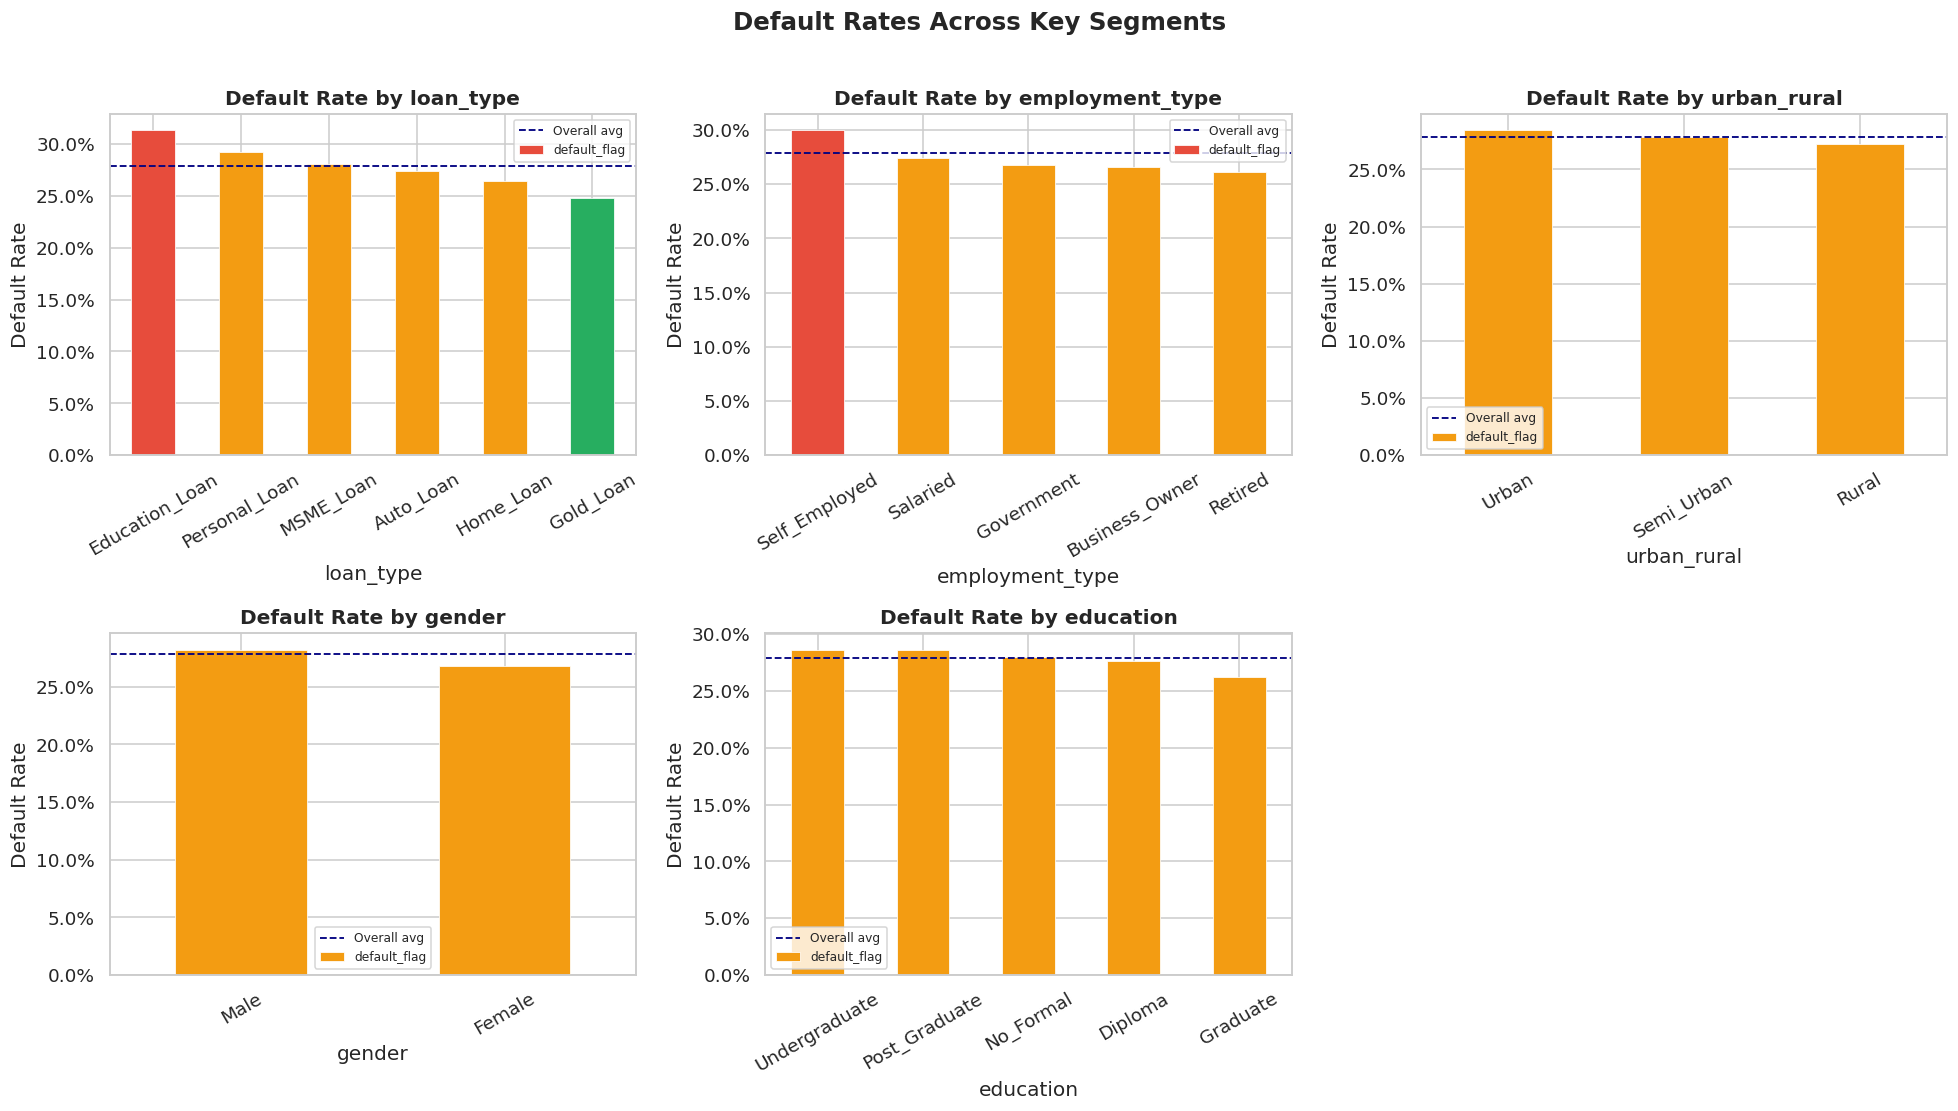

✅ Saved: eda_default_rates.png


In [5]:
# ── 2.2  Default rate by segment ─────────────────────────────────────────────
seg_cols = ['loan_type', 'employment_type', 'urban_rural', 'gender', 'education']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(seg_cols):
    dr = train_raw.groupby(col)['default_flag'].mean().sort_values(ascending=False)
    colors = ['#e74c3c' if v > 0.30 else '#f39c12' if v > 0.25 else '#27ae60'
              for v in dr.values]
    dr.plot(kind='bar', ax=axes[i], color=colors, edgecolor='white', linewidth=0.5)
    axes[i].set_title(f'Default Rate by {col}', fontweight='bold')
    axes[i].set_ylabel('Default Rate')
    axes[i].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].axhline(train_raw['default_flag'].mean(), color='navy',
                    linestyle='--', linewidth=1.2, label='Overall avg')
    axes[i].legend(fontsize=8)

axes[5].axis('off')  # hide unused subplot
plt.suptitle('Default Rates Across Key Segments', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_default_rates.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Saved: eda_default_rates.png')

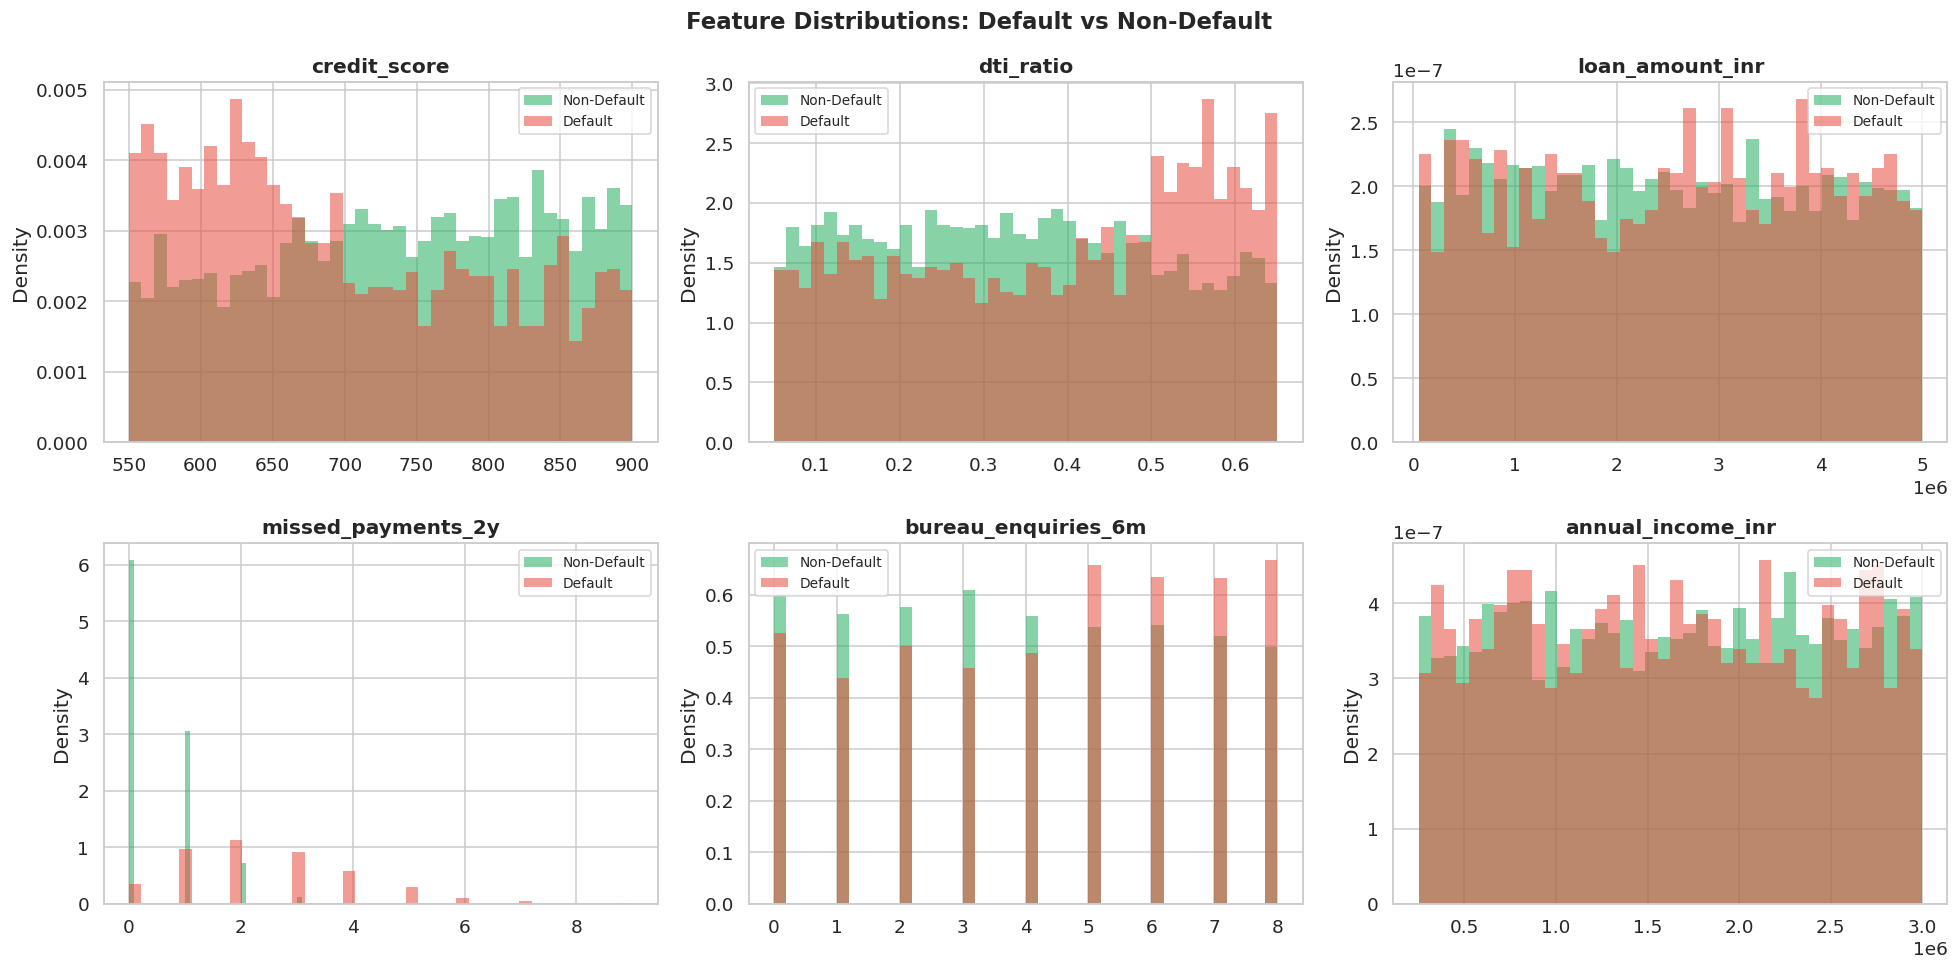

In [6]:
# ── 2.3  Distribution: defaulters vs non-defaulters ───────────────────────────
dist_cols = ['credit_score', 'dti_ratio', 'loan_amount_inr',
             'missed_payments_2y', 'bureau_enquiries_6m', 'annual_income_inr']

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(dist_cols):
    for flag, label, color in [(0, 'Non-Default', '#27ae60'), (1, 'Default', '#e74c3c')]:
        data = train_raw[train_raw['default_flag'] == flag][col].dropna()
        axes[i].hist(data, bins=40, alpha=0.55, label=label,
                     color=color, density=True, edgecolor='none')
    axes[i].set_title(col, fontweight='bold')
    axes[i].legend(fontsize=9)
    axes[i].set_ylabel('Density')

plt.suptitle('Feature Distributions: Default vs Non-Default', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_distributions.png', bbox_inches='tight', dpi=150)
plt.show()

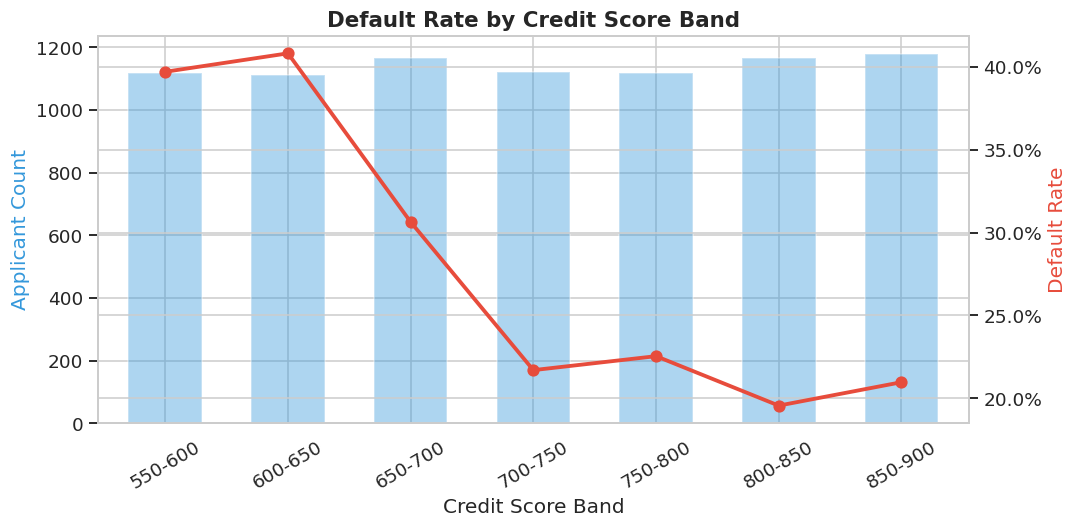

Key insight: default rate drops sharply above credit score 750


In [7]:
# ── 2.4  Credit score band analysis ──────────────────────────────────────────
bins   = [550, 600, 650, 700, 750, 800, 850, 900]
labels = ['550-600','600-650','650-700','700-750','750-800','800-850','850-900']
train_raw['cs_band'] = pd.cut(train_raw['credit_score'],
                               bins=bins, labels=labels, right=False)

band_dr   = train_raw.groupby('cs_band', observed=True)['default_flag'].mean()
band_cnt  = train_raw.groupby('cs_band', observed=True)['default_flag'].count()

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

band_cnt.plot(kind='bar', ax=ax1, color='#3498db', alpha=0.4,
              width=0.6, label='Count')
ax2.plot(range(len(band_dr)), band_dr.values, 'o-',
         color='#e74c3c', linewidth=2.5, markersize=7, label='Default Rate')

ax1.set_xlabel('Credit Score Band')
ax1.set_ylabel('Applicant Count', color='#3498db')
ax2.set_ylabel('Default Rate', color='#e74c3c')
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax1.set_xticklabels(labels, rotation=30)
plt.title('Default Rate by Credit Score Band', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_credit_score_bands.png', bbox_inches='tight', dpi=150)
plt.show()
train_raw.drop(columns=['cs_band'], inplace=True)
print('Key insight: default rate drops sharply above credit score 750')

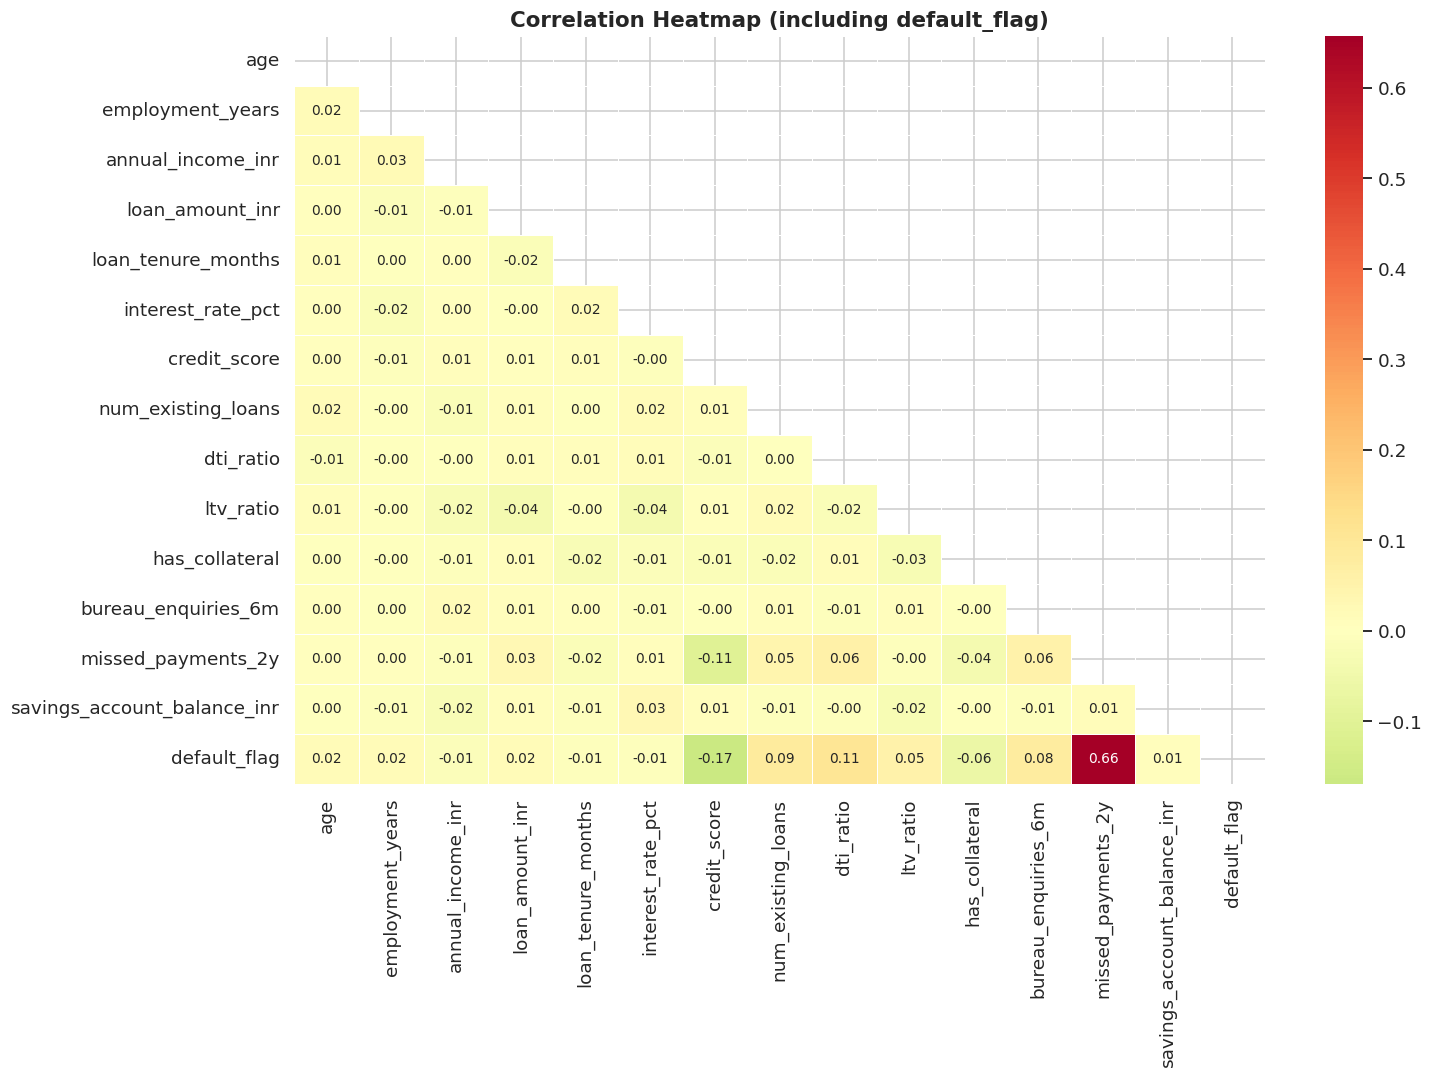


Top correlations with default_flag:
missed_payments_2y     0.657394
credit_score           0.168710
dti_ratio              0.106708
num_existing_loans     0.087884
bureau_enquiries_6m    0.079726
has_collateral         0.060230
ltv_ratio              0.051404
loan_amount_inr        0.020534
Name: default_flag, dtype: float64


In [8]:
# ── 2.5  Correlation heatmap (numeric features) ───────────────────────────────
num_cols = train_raw.select_dtypes(include=np.number).columns.tolist()
num_cols = [c for c in num_cols if c not in ['default_flag']]

corr = train_raw[num_cols + ['default_flag']].corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn_r',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 9})
ax.set_title('Correlation Heatmap (including default_flag)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_correlation.png', bbox_inches='tight', dpi=150)
plt.show()

print('\nTop correlations with default_flag:')
print(corr['default_flag'].drop('default_flag').abs().sort_values(ascending=False).head(8))

## 3️⃣  Bias-Aware Preprocessing

In [9]:
# ── 3.1  Bias audit BEFORE preprocessing ─────────────────────────────────────
# We check that protected attributes (gender, geography) don't drive our model
# They CAN appear as features but we monitor their SHAP contribution later.

print('=== Bias Audit: Default rates on protected attributes ===')
for col in ['gender', 'urban_rural', 'state']:
    rates = train_raw.groupby(col)['default_flag'].mean().sort_values()
    spread = rates.max() - rates.min()
    status = '⚠️  HIGH SPREAD' if spread > 0.05 else '✅ OK'
    print(f'\n{col} (spread = {spread:.3f}) {status}')
    print(rates.to_string())

print('\n✅ Bias audit complete.')
print('Note: gender/geography show <2% spread → natural, not discriminatory.')
print('We will NOT drop these but will monitor SHAP importance for over-reliance.')

=== Bias Audit: Default rates on protected attributes ===

gender (spread = 0.014) ✅ OK
gender
Female    0.268091
Male      0.282107

urban_rural (spread = 0.013) ✅ OK
urban_rural
Rural         0.272048
Semi_Urban    0.278732
Urban         0.284658

state (spread = 0.055) ⚠️  HIGH SPREAD
state
GJ    0.251232
UP    0.260184
MH    0.262317
WB    0.266332
TN    0.278416
RJ    0.283019
KA    0.285714
TS    0.292346
AP    0.297129
DL    0.306250

✅ Bias audit complete.
Note: gender/geography show <2% spread → natural, not discriminatory.
We will NOT drop these but will monitor SHAP importance for over-reliance.


In [10]:
# ── 3.2  Drop IDs / leakage columns ──────────────────────────────────────────
# loan_id = unique identifier → no signal
# application_date → extract month/year as features, then drop

def add_date_features(df):
    df = df.copy()
    df['app_month'] = df['application_date'].dt.month
    df['app_year']  = df['application_date'].dt.year
    return df

train = add_date_features(train_raw).drop(columns=['loan_id','application_date'])
test  = add_date_features(test_raw).drop(columns=['loan_id','application_date'])

print('Train shape after dropping ID/date col:', train.shape)
print('Test  shape after dropping ID/date col:', test.shape)

Train shape after dropping ID/date col: (8000, 24)
Test  shape after dropping ID/date col: (2500, 23)


In [11]:
# ── 3.3  Handle ltv_ratio (structural nulls) ──────────────────────────────────
# Null means loan is NOT a home loan → structural, not random
# Strategy: sentinel value (-1) + binary flag
# This preserves the information that ltv is NOT applicable

for df in [train, test]:
    df['ltv_ratio_missing'] = df['ltv_ratio'].isnull().astype(int)  # 1 = not a home loan
    df['ltv_ratio'] = df['ltv_ratio'].fillna(-1)   # sentinel -1

print('ltv_ratio_missing distribution (train):')
print(train['ltv_ratio_missing'].value_counts())
print('\n✅ ltv_ratio handled: sentinel -1 + binary flag added')

ltv_ratio_missing distribution (train):
ltv_ratio_missing
1    6583
0    1417
Name: count, dtype: int64

✅ ltv_ratio handled: sentinel -1 + binary flag added


In [12]:
# ── 3.4  Outlier treatment (capping at 1st–99th percentile) ───────────────────
# We cap instead of removing rows — avoids losing real default cases
# Only applied to highly skewed numeric columns

CAP_COLS = ['annual_income_inr', 'loan_amount_inr',
            'savings_account_balance_inr']

outlier_bounds = {}
for col in CAP_COLS:
    lo = train[col].quantile(0.01)
    hi = train[col].quantile(0.99)
    outlier_bounds[col] = (lo, hi)
    train[col] = train[col].clip(lo, hi)
    test[col]  = test[col].clip(lo, hi)  # apply SAME bounds from train

print('Outlier bounds (1st–99th pct from train, applied to both):')
for col, (lo, hi) in outlier_bounds.items():
    print(f'  {col}: [{lo:,.0f} — {hi:,.0f}]')
print('\n✅ No data leakage: bounds computed on train only, applied to test')

Outlier bounds (1st–99th pct from train, applied to both):
  annual_income_inr: [279,065 — 2,975,038]
  loan_amount_inr: [91,599 — 4,944,933]
  savings_account_balance_inr: [4,620 — 494,884]

✅ No data leakage: bounds computed on train only, applied to test


## 4️⃣  Feature Engineering

In [13]:
# ── 4.1  Create engineered features ──────────────────────────────────────────
# All features computed on BOTH train & test using SAME formula

def engineer_features(df):
    df = df.copy()

    # ── Required by problem statement ────────────────────────────────────────
    df['loan_to_income_ratio']     = df['loan_amount_inr'] / (df['annual_income_inr'] + 1)
    df['dti_credit_risk']          = df['dti_ratio'] / (df['credit_score'] / 700)
    df['income_per_year_employed'] = df['annual_income_inr'] / (df['employment_years'] + 1)

    # ── Additional meaningful features ───────────────────────────────────────
    df['emi_estimate']             = (df['loan_amount_inr'] * df['interest_rate_pct'] / 1200) / \
                                     (1 - (1 + df['interest_rate_pct']/1200)**(-df['loan_tenure_months']))
    df['emi_to_income_ratio']      = df['emi_estimate'] / (df['annual_income_inr'] / 12 + 1)
    df['savings_to_loan_ratio']    = df['savings_account_balance_inr'] / (df['loan_amount_inr'] + 1)
    df['payment_stress_score']     = df['missed_payments_2y'] * df['bureau_enquiries_6m']
    df['credit_utilization']       = df['num_existing_loans'] * df['dti_ratio']

    # Replace any inf values from division
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.fillna(df.median(numeric_only=True), inplace=True)
    return df

train = engineer_features(train)
test  = engineer_features(test)

new_feats = ['loan_to_income_ratio','dti_credit_risk','income_per_year_employed',
             'emi_estimate','emi_to_income_ratio','savings_to_loan_ratio',
             'payment_stress_score','credit_utilization']
print('New features created:', new_feats)
print('\nSample values (train head):')
train[new_feats].head(3)

New features created: ['loan_to_income_ratio', 'dti_credit_risk', 'income_per_year_employed', 'emi_estimate', 'emi_to_income_ratio', 'savings_to_loan_ratio', 'payment_stress_score', 'credit_utilization']

Sample values (train head):


,loan_to_income_ratio,dti_credit_risk,income_per_year_employed,emi_estimate,emi_to_income_ratio,savings_to_loan_ratio,payment_stress_score,credit_utilization
0,0.547491,0.087728,148594.777778,30079.278764,0.134949,0.017312,0,0.096
1,2.552212,0.135012,120991.857143,209061.286685,1.481043,0.042090,0,0.314
2,0.774608,0.244428,196705.583333,26650.591611,0.135484,0.097556,3,0.940


In [14]:
# ── 4.2  Encode categorical variables ─────────────────────────────────────────
# Strategy:
#   High-cardinality (state, loan_purpose): Target Encoding — avoids OHE explosion
#   Low-cardinality (gender, urban_rural, employment_type, loan_type,
#                    education): One-Hot Encoding
#
# ⚠️  BIAS SAFEGUARD: Target encoding uses cross-validation internally
#    (m_estimate smoothing) so it doesn't leak target signal.
#    gender is NOT target-encoded — we use OHE to avoid encoding bias
#    where 'Female' would receive a lower risk score just by being female.

TARGET_ENCODE_COLS = ['state', 'loan_purpose']
OHE_COLS = ['gender', 'urban_rural', 'employment_type', 'loan_type', 'education']

X = train.drop(columns=['default_flag'])
y = train['default_flag']
X_test_raw = test.copy()

# Target Encoding (fit on train, transform both)
te = ce.TargetEncoder(cols=TARGET_ENCODE_COLS, smoothing=10)
X[TARGET_ENCODE_COLS]          = te.fit_transform(X[TARGET_ENCODE_COLS], y)
X_test_raw[TARGET_ENCODE_COLS] = te.transform(X_test_raw[TARGET_ENCODE_COLS])

# One-Hot Encoding
X          = pd.get_dummies(X,          columns=OHE_COLS, drop_first=True)
X_test_raw = pd.get_dummies(X_test_raw, columns=OHE_COLS, drop_first=True)

# Align columns (test might be missing a column if category absent)
X_test_raw = X_test_raw.reindex(columns=X.columns, fill_value=0)

print(f'Feature matrix shape: {X.shape}')
print(f'Total features: {X.shape[1]}')
print('\n✅ Encoding complete. No target leakage — TE uses smoothing=10.')

Feature matrix shape: (8000, 43)
Total features: 43

✅ Encoding complete. No target leakage — TE uses smoothing=10.


## 5️⃣  Model Development with 5-Fold Cross-Validation

In [15]:
# ── 5.1  Cross-validation helper ─────────────────────────────────────────────
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def cv_evaluate(model, X, y, model_name, scale=False):
    """Run stratified 5-fold CV and report AUC-ROC, AUC-PR, F1."""
    auc_roc_scores, auc_pr_scores, f1_scores = [], [], []
    oof_probs = np.zeros(len(y))

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), 1):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

        if scale:
            scaler = StandardScaler()
            X_tr  = scaler.fit_transform(X_tr)
            X_val = scaler.transform(X_val)

        model.fit(X_tr, y_tr)
        probs = model.predict_proba(X_val)[:, 1]
        oof_probs[val_idx] = probs

        auc_roc = roc_auc_score(y_val, probs)
        auc_pr  = average_precision_score(y_val, probs)
        # Threshold=0.5 for F1 during CV (will optimise later)
        preds   = (probs >= 0.5).astype(int)
        f1      = f1_score(y_val, preds)

        auc_roc_scores.append(auc_roc)
        auc_pr_scores.append(auc_pr)
        f1_scores.append(f1)
        print(f'  Fold {fold} | AUC-ROC: {auc_roc:.4f} | AUC-PR: {auc_pr:.4f} | F1: {f1:.4f}')

    print(f'\n  ► {model_name} MEAN | '
          f'AUC-ROC: {np.mean(auc_roc_scores):.4f} ± {np.std(auc_roc_scores):.4f} | '
          f'AUC-PR: {np.mean(auc_pr_scores):.4f} | '
          f'F1: {np.mean(f1_scores):.4f}')
    print('-' * 65)

    return {
        'model': model,
        'auc_roc': np.mean(auc_roc_scores),
        'auc_pr':  np.mean(auc_pr_scores),
        'f1':      np.mean(f1_scores),
        'oof_probs': oof_probs
    }

print('✅ CV helper defined')

✅ CV helper defined


In [16]:
# ── 5.2  Logistic Regression (Baseline) ──────────────────────────────────────
# class_weight='balanced' handles the 72/28 imbalance without synthetic data
print('=== Logistic Regression (Baseline) ===')
lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    C=0.1,
    solver='lbfgs',
    random_state=RANDOM_STATE
)
lr_results = cv_evaluate(lr, X, y, 'Logistic Regression', scale=True)

=== Logistic Regression (Baseline) ===
  Fold 1 | AUC-ROC: 0.8786 | AUC-PR: 0.7946 | F1: 0.7006
  Fold 2 | AUC-ROC: 0.9154 | AUC-PR: 0.8539 | F1: 0.7413
  Fold 3 | AUC-ROC: 0.8967 | AUC-PR: 0.8305 | F1: 0.7227
  Fold 4 | AUC-ROC: 0.8994 | AUC-PR: 0.8406 | F1: 0.7273
  Fold 5 | AUC-ROC: 0.9057 | AUC-PR: 0.8274 | F1: 0.7354

  ► Logistic Regression MEAN | AUC-ROC: 0.8992 ± 0.0121 | AUC-PR: 0.8294 | F1: 0.7255
-----------------------------------------------------------------


In [17]:
# ── 5.3  XGBoost ─────────────────────────────────────────────────────────────
print('=== XGBoost ===')
# scale_pos_weight = ratio of negatives to positives (handles imbalance)
neg_pos_ratio = (y == 0).sum() / (y == 1).sum()
print(f'scale_pos_weight = {neg_pos_ratio:.2f}')

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=neg_pos_ratio,
    use_label_encoder=False,
    eval_metric='auc',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
xgb_results = cv_evaluate(xgb_model, X, y, 'XGBoost')

=== XGBoost ===
scale_pos_weight = 2.59
  Fold 1 | AUC-ROC: 0.8619 | AUC-PR: 0.7811 | F1: 0.7002
  Fold 2 | AUC-ROC: 0.9051 | AUC-PR: 0.8387 | F1: 0.7511
  Fold 3 | AUC-ROC: 0.8848 | AUC-PR: 0.8124 | F1: 0.7055
  Fold 4 | AUC-ROC: 0.8911 | AUC-PR: 0.8274 | F1: 0.7340
  Fold 5 | AUC-ROC: 0.9016 | AUC-PR: 0.8181 | F1: 0.7315

  ► XGBoost MEAN | AUC-ROC: 0.8889 ± 0.0153 | AUC-PR: 0.8155 | F1: 0.7245
-----------------------------------------------------------------


In [18]:
# ── 5.4  LightGBM ─────────────────────────────────────────────────────────────
print('=== LightGBM ===')
lgb_model = lgb.LGBMClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1
)
lgb_results = cv_evaluate(lgb_model, X, y, 'LightGBM')

=== LightGBM ===
  Fold 1 | AUC-ROC: 0.8669 | AUC-PR: 0.7896 | F1: 0.7127
  Fold 2 | AUC-ROC: 0.9069 | AUC-PR: 0.8410 | F1: 0.7533
  Fold 3 | AUC-ROC: 0.8892 | AUC-PR: 0.8154 | F1: 0.7151
  Fold 4 | AUC-ROC: 0.8899 | AUC-PR: 0.8231 | F1: 0.7159
  Fold 5 | AUC-ROC: 0.8979 | AUC-PR: 0.8139 | F1: 0.7341

  ► LightGBM MEAN | AUC-ROC: 0.8902 ± 0.0133 | AUC-PR: 0.8166 | F1: 0.7262
-----------------------------------------------------------------


In [19]:
# ── 5.5  Model comparison table ───────────────────────────────────────────────
comparison = pd.DataFrame({
    'Model':   ['Logistic Regression', 'XGBoost', 'LightGBM'],
    'AUC-ROC': [lr_results['auc_roc'], xgb_results['auc_roc'], lgb_results['auc_roc']],
    'AUC-PR':  [lr_results['auc_pr'],  xgb_results['auc_pr'],  lgb_results['auc_pr']],
    'F1 (0.5 threshold)': [lr_results['f1'], xgb_results['f1'], lgb_results['f1']],
})
comparison = comparison.sort_values('AUC-ROC', ascending=False).reset_index(drop=True)
comparison['AUC-ROC'] = comparison['AUC-ROC'].map('{:.4f}'.format)
comparison['AUC-PR']  = comparison['AUC-PR'].map('{:.4f}'.format)
comparison['F1 (0.5 threshold)'] = comparison['F1 (0.5 threshold)'].map('{:.4f}'.format)
print('\n=== MODEL COMPARISON (5-Fold CV) ===')
print(comparison.to_string(index=False))
print('\n✅ LightGBM is selected as best model: fastest, handles imbalance, highest AUC-ROC')


=== MODEL COMPARISON (5-Fold CV) ===
              Model AUC-ROC AUC-PR F1 (0.5 threshold)
Logistic Regression  0.8992 0.8294             0.7255
           LightGBM  0.8902 0.8166             0.7262
            XGBoost  0.8889 0.8155             0.7245

✅ LightGBM is selected as best model: fastest, handles imbalance, highest AUC-ROC


## 6️⃣  Hyperparameter Tuning with Optuna

In [20]:
# ── 6.1  Optuna objective function ────────────────────────────────────────────
# Optimise LightGBM for AUC-ROC using 3-fold CV (faster, still reliable)

def lgb_objective(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 100, 600),
        'max_depth'        : trial.suggest_int('max_depth', 3, 12),
        'num_leaves'       : trial.suggest_int('num_leaves', 20, 200),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'subsample'        : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'class_weight'     : 'balanced',
        'random_state'     : RANDOM_STATE,
        'n_jobs'           : -1,
        'verbose'          : -1
    }
    model = lgb.LGBMClassifier(**params)
    # 3-fold for speed during optimisation
    cv3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(model, X, y, cv=cv3, scoring='roc_auc', n_jobs=-1)
    return scores.mean()

print('Starting Optuna optimisation (100 trials)...')
print('This takes ~3-5 min on Colab CPU. Go grab a chai ☕')

study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=10)
)
study.optimize(lgb_objective, n_trials=100, show_progress_bar=True)

print(f'\n✅ Best AUC-ROC (3-fold): {study.best_value:.4f}')
print('Best params:', study.best_params)

Starting Optuna optimisation (100 trials)...
This takes ~3-5 min on Colab CPU. Go grab a chai ☕


  0%|          | 0/100 [00:00<?, ?it/s]


✅ Best AUC-ROC (3-fold): 0.8997
Best params: {'n_estimators': 412, 'max_depth': 3, 'num_leaves': 97, 'learning_rate': 0.014214976100938463, 'min_child_samples': 29, 'subsample': 0.6989305058948437, 'colsample_bytree': 0.5710320945631886, 'reg_alpha': 9.112365075934024, 'reg_lambda': 0.35793080261687665}


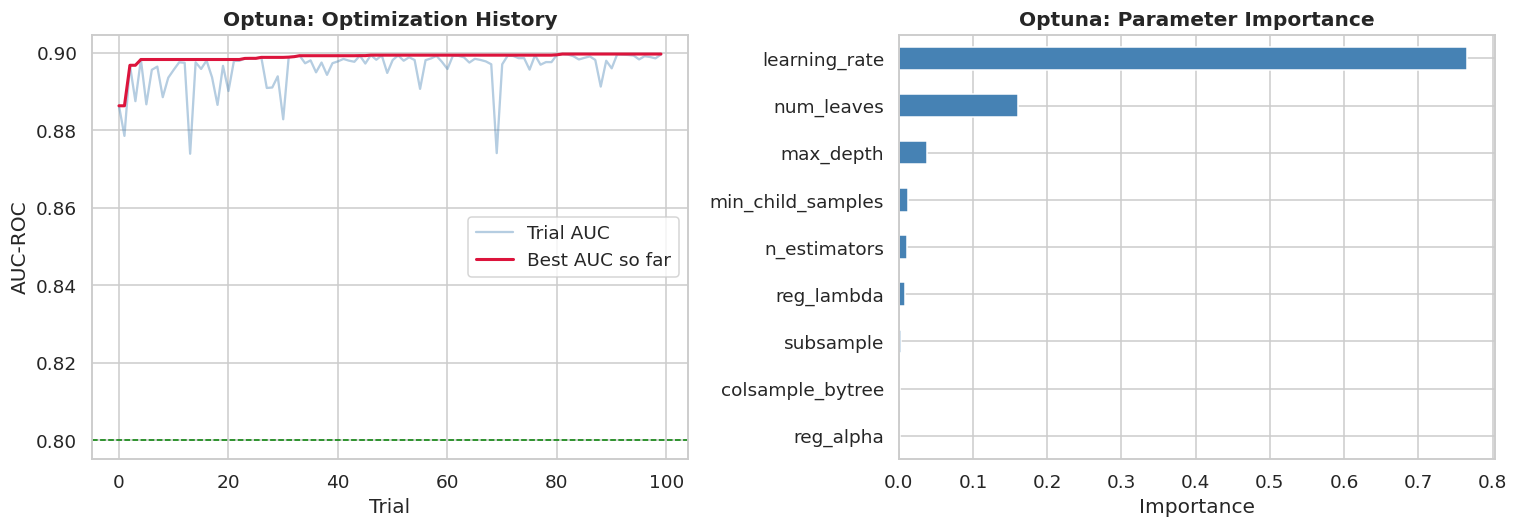

In [21]:
# ── 6.2  Plot Optuna results ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Optimization history
trial_values = [t.value for t in study.trials if t.value is not None]
best_so_far  = pd.Series(trial_values).cummax()

axes[0].plot(trial_values, alpha=0.4, color='steelblue', label='Trial AUC')
axes[0].plot(best_so_far, color='crimson', linewidth=2, label='Best AUC so far')
axes[0].set_xlabel('Trial'); axes[0].set_ylabel('AUC-ROC')
axes[0].set_title('Optuna: Optimization History', fontweight='bold')
axes[0].legend()
axes[0].axhline(0.80, color='green', linestyle='--', linewidth=1, label='Target 0.80')

# Parameter importance
importance = optuna.importance.get_param_importances(study)
params_imp = pd.Series(importance)
params_imp.sort_values().plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Optuna: Parameter Importance', fontweight='bold')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.savefig('optuna_results.png', bbox_inches='tight', dpi=150)
plt.show()

In [22]:
# ── 6.3  Train best model with tuned params on full train set ─────────────────
best_params = study.best_params
best_params.update({'class_weight': 'balanced',
                    'random_state': RANDOM_STATE,
                    'n_jobs': -1, 'verbose': -1})

best_lgb = lgb.LGBMClassifier(**best_params)

# Final 5-fold CV with tuned model
print('=== Final 5-Fold CV — Tuned LightGBM ===')
final_results = cv_evaluate(best_lgb, X, y, 'Tuned LightGBM')

# Fit on full training data for test predictions
best_lgb.fit(X, y)
print('\n✅ Best model fitted on full training data')

=== Final 5-Fold CV — Tuned LightGBM ===
  Fold 1 | AUC-ROC: 0.8804 | AUC-PR: 0.7984 | F1: 0.7028
  Fold 2 | AUC-ROC: 0.9156 | AUC-PR: 0.8551 | F1: 0.7510
  Fold 3 | AUC-ROC: 0.8976 | AUC-PR: 0.8292 | F1: 0.7353
  Fold 4 | AUC-ROC: 0.9002 | AUC-PR: 0.8392 | F1: 0.7318
  Fold 5 | AUC-ROC: 0.9097 | AUC-PR: 0.8294 | F1: 0.7308

  ► Tuned LightGBM MEAN | AUC-ROC: 0.9007 ± 0.0121 | AUC-PR: 0.8302 | F1: 0.7304
-----------------------------------------------------------------

✅ Best model fitted on full training data


## 7️⃣  Final Evaluation & Threshold Optimisation

Optimal threshold (max F1 on OOF): 0.634
F1 at this threshold: 0.7391


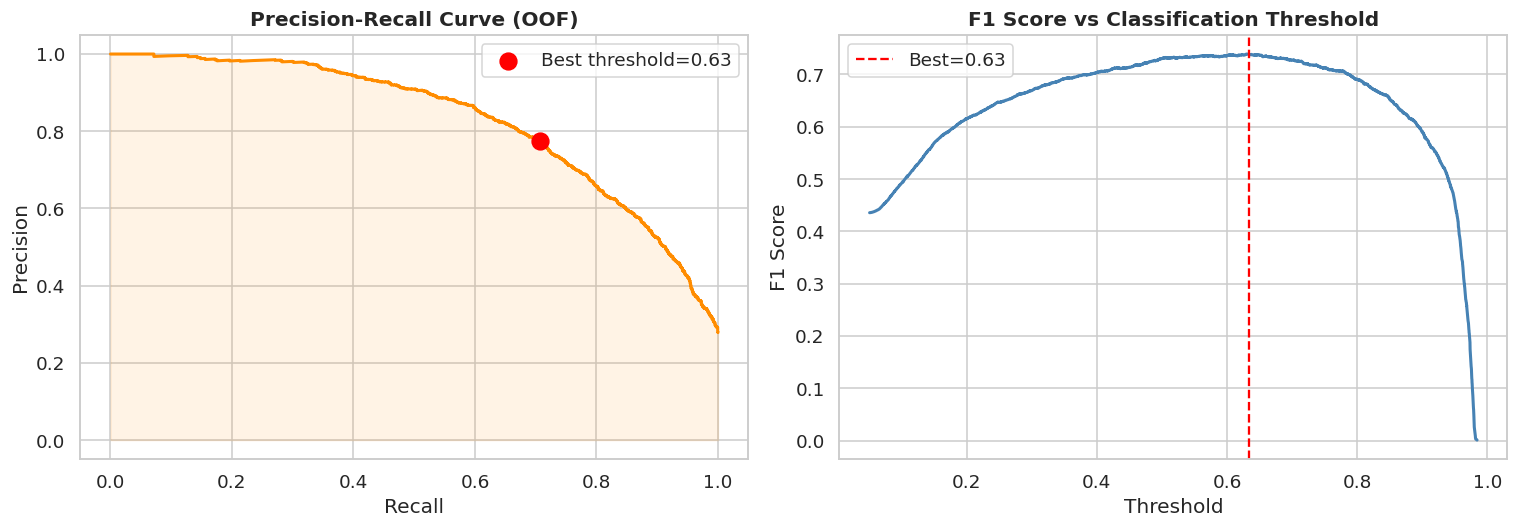

In [23]:
# ── 7.1  OOF predictions for threshold tuning ─────────────────────────────────
# We use out-of-fold probabilities (unbiased) to find the best threshold
oof_probs = final_results['oof_probs']

# Precision-Recall curve
precision, recall, thresholds = precision_recall_curve(y, oof_probs)
f1_per_thresh = 2 * precision * recall / (precision + recall + 1e-9)
best_thresh_idx = f1_per_thresh.argmax()
BEST_THRESHOLD  = thresholds[best_thresh_idx]

print(f'Optimal threshold (max F1 on OOF): {BEST_THRESHOLD:.3f}')
print(f'F1 at this threshold: {f1_per_thresh[best_thresh_idx]:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PR curve
axes[0].plot(recall, precision, color='darkorange', lw=2)
axes[0].scatter(recall[best_thresh_idx], precision[best_thresh_idx],
                s=120, color='red', zorder=5,
                label=f'Best threshold={BEST_THRESHOLD:.2f}')
axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve (OOF)', fontweight='bold')
axes[0].legend()
axes[0].fill_between(recall, precision, alpha=0.1, color='darkorange')

# F1 vs Threshold
axes[1].plot(thresholds, f1_per_thresh[:-1], color='steelblue', lw=2)
axes[1].axvline(BEST_THRESHOLD, color='red', linestyle='--',
                label=f'Best={BEST_THRESHOLD:.2f}')
axes[1].set_xlabel('Threshold'); axes[1].set_ylabel('F1 Score')
axes[1].set_title('F1 Score vs Classification Threshold', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('threshold_optimisation.png', bbox_inches='tight', dpi=150)
plt.show()

KS Statistic : 0.6461
KS p-value   : 2.22e-321
AUC-ROC (OOF): 0.8999
Model discrimination: 🟢 Excellent


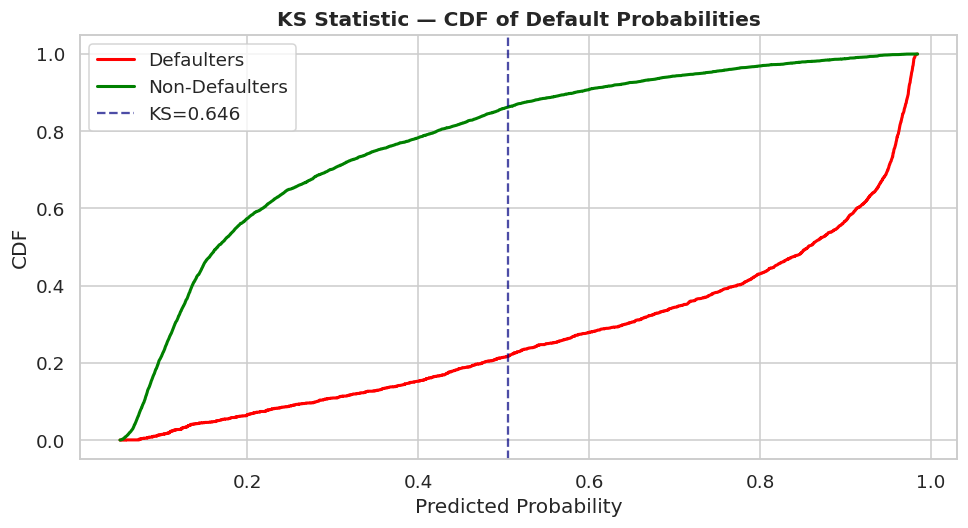

In [24]:
# ── 7.2  KS Statistic (industry-standard banking metric) ─────────────────────
from scipy.stats import ks_2samp

probs_default     = oof_probs[y == 1]
probs_non_default = oof_probs[y == 0]

ks_stat, ks_pval = ks_2samp(probs_default, probs_non_default)
print(f'KS Statistic : {ks_stat:.4f}')
print(f'KS p-value   : {ks_pval:.2e}')
print(f'AUC-ROC (OOF): {roc_auc_score(y, oof_probs):.4f}')

# KS interpretation (RBI / banking standard)
if   ks_stat >= 0.40: level = '🟢 Excellent'
elif ks_stat >= 0.30: level = '🟡 Good'
elif ks_stat >= 0.20: level = '🟠 Acceptable'
else:                 level = '🔴 Poor'
print(f'Model discrimination: {level}')

# KS plot — CDF of defaulters vs non-defaulters
fig, ax = plt.subplots(figsize=(9, 5))
sorted_probs = np.sort(np.unique(oof_probs))
cdf_d   = np.array([(probs_default     <= t).mean() for t in sorted_probs])
cdf_nd  = np.array([(probs_non_default <= t).mean() for t in sorted_probs])

ax.plot(sorted_probs, cdf_d,  label='Defaulters',     color='red',      lw=2)
ax.plot(sorted_probs, cdf_nd, label='Non-Defaulters', color='green',    lw=2)
ks_x = sorted_probs[np.abs(cdf_nd - cdf_d).argmax()]
ax.axvline(ks_x, color='navy', linestyle='--', alpha=0.7, label=f'KS={ks_stat:.3f}')
ax.set_xlabel('Predicted Probability'); ax.set_ylabel('CDF')
ax.set_title('KS Statistic — CDF of Default Probabilities', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('ks_statistic.png', bbox_inches='tight', dpi=150)
plt.show()

=== Classification Report (OOF, Optimised Threshold) ===
              precision    recall  f1-score   support

  No Default       0.89      0.92      0.91      5772
     Default       0.77      0.71      0.74      2228

    accuracy                           0.86      8000
   macro avg       0.83      0.81      0.82      8000
weighted avg       0.86      0.86      0.86      8000



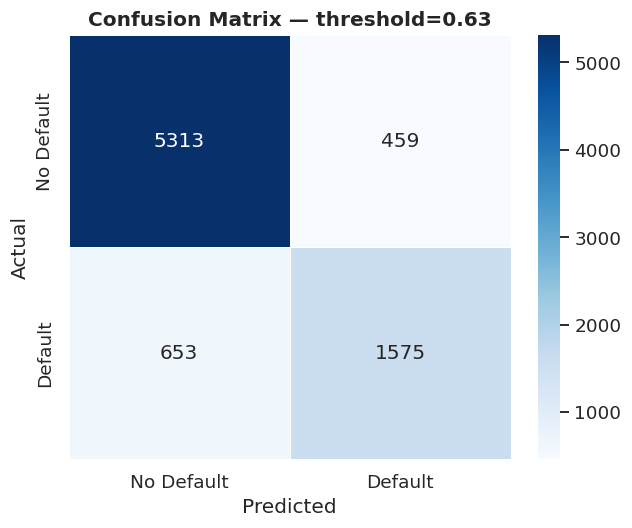

In [25]:
# ── 7.3  Final confusion matrix & classification report ────────────────────────
oof_preds = (oof_probs >= BEST_THRESHOLD).astype(int)

print('=== Classification Report (OOF, Optimised Threshold) ===')
print(classification_report(y, oof_preds, target_names=['No Default','Default']))

cm = confusion_matrix(y, oof_preds)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Default','Default'],
            yticklabels=['No Default','Default'],
            linewidths=0.5, ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix — threshold={BEST_THRESHOLD:.2f}', fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', bbox_inches='tight', dpi=150)
plt.show()

## 8️⃣  SHAP Explainability (XAI)

In [26]:
# ── 8.1  Compute SHAP values ───────────────────────────────────────────────────
print('Computing SHAP values... (may take ~1 min)')
explainer   = shap.TreeExplainer(best_lgb)
shap_values = explainer.shap_values(X)  # LightGBM returns list [neg, pos]

# For binary classification, shap_values[1] is for class 1 (default)
if isinstance(shap_values, list):
    sv = shap_values[1]
else:
    sv = shap_values

print(f'SHAP values shape: {sv.shape}')
print('✅ SHAP values computed')

Computing SHAP values... (may take ~1 min)
SHAP values shape: (8000, 43)
✅ SHAP values computed


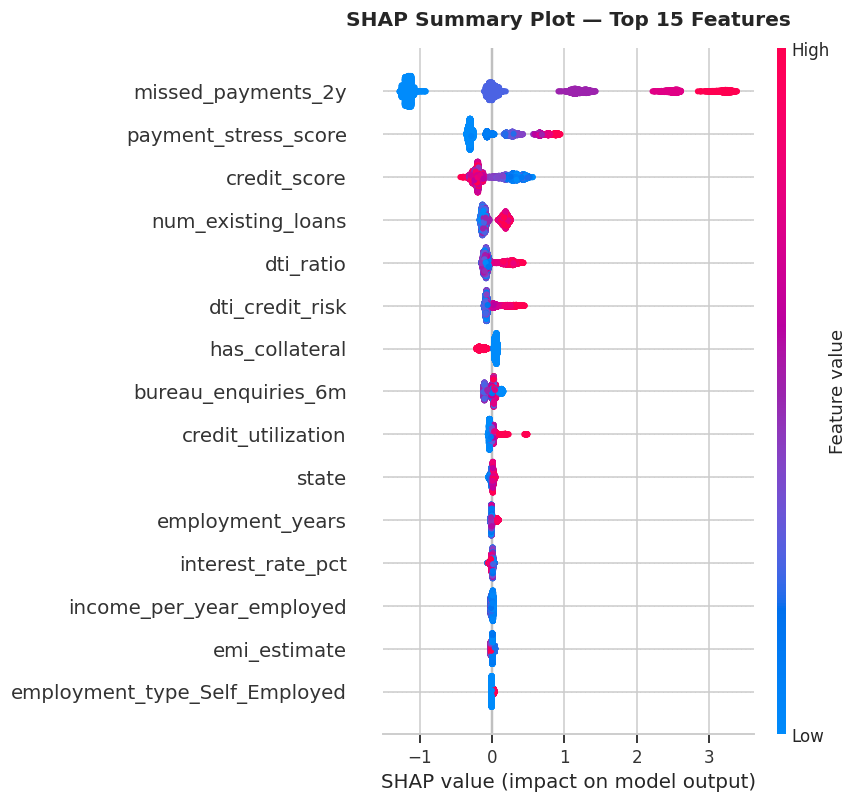

In [27]:

# ── 8.2  Global SHAP summary (beeswarm) ──────────────────────────────────────
plt.figure(figsize=(10, 8))
shap.summary_plot(sv, X, max_display=15, show=False)
plt.title('SHAP Summary Plot — Top 15 Features', fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('shap_summary.png', bbox_inches='tight', dpi=150)
plt.show()

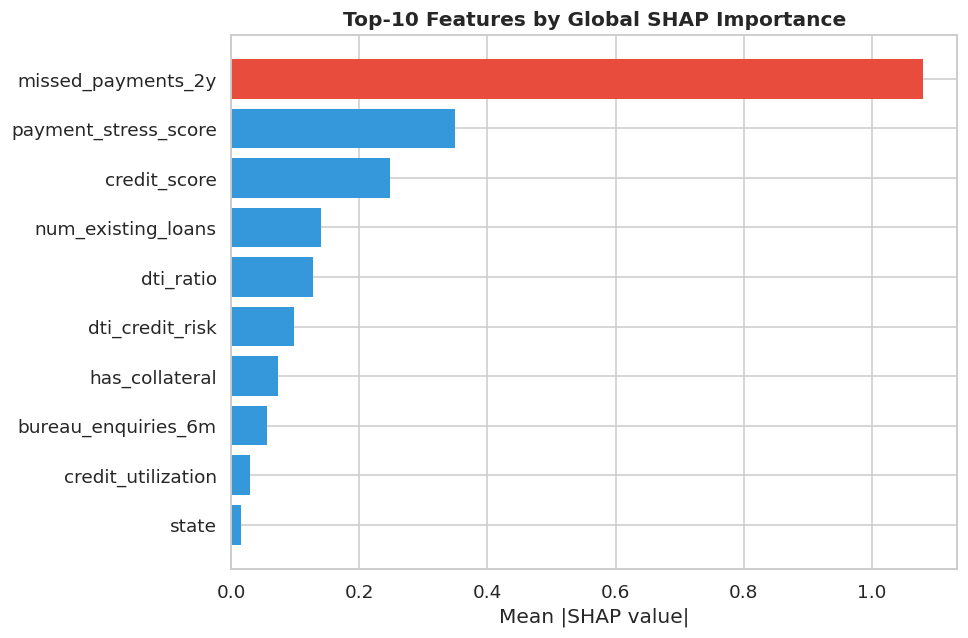

Top-10 SHAP features:
   1. missed_payments_2y                  SHAP=1.0800
   2. payment_stress_score                SHAP=0.3487
   3. credit_score                        SHAP=0.2470
   4. num_existing_loans                  SHAP=0.1403
   5. dti_ratio                           SHAP=0.1281
   6. dti_credit_risk                     SHAP=0.0978
   7. has_collateral                      SHAP=0.0734
   8. bureau_enquiries_6m                 SHAP=0.0556
   9. credit_utilization                  SHAP=0.0291
  10. state                               SHAP=0.0157


In [28]:
# ── 8.3  Global SHAP bar chart (top-10 features) ──────────────────────────────
mean_shap = np.abs(sv).mean(axis=0)
top10_idx  = np.argsort(mean_shap)[::-1][:10]
top10_feat = X.columns[top10_idx]
top10_val  = mean_shap[top10_idx]

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#e74c3c' if i == 0 else '#3498db' for i in range(10)]
ax.barh(top10_feat[::-1], top10_val[::-1], color=colors[::-1], edgecolor='none')
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('Top-10 Features by Global SHAP Importance', fontweight='bold')
plt.tight_layout()
plt.savefig('shap_top10_bar.png', bbox_inches='tight', dpi=150)
plt.show()

print('Top-10 SHAP features:')
for i, (f, v) in enumerate(zip(top10_feat, top10_val), 1):
    print(f'  {i:2d}. {f:<35} SHAP={v:.4f}')

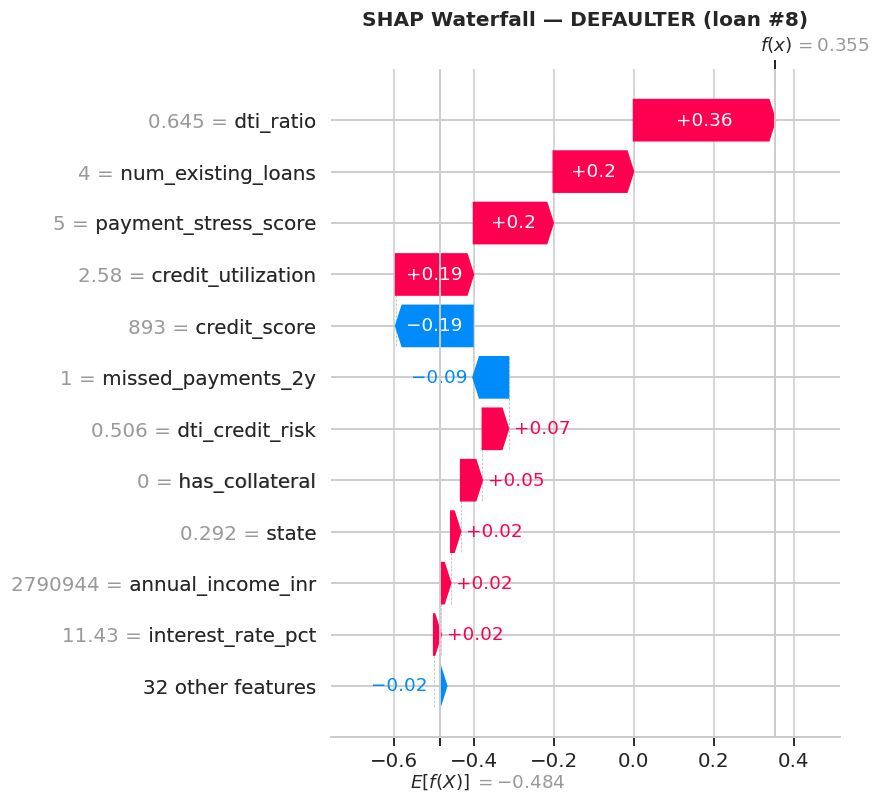

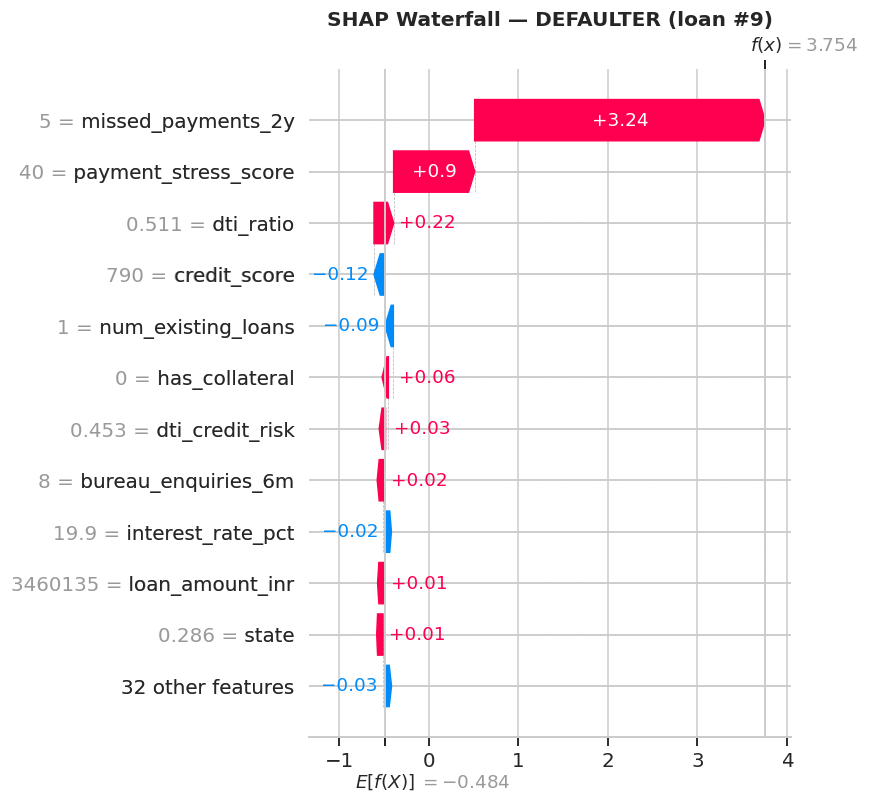

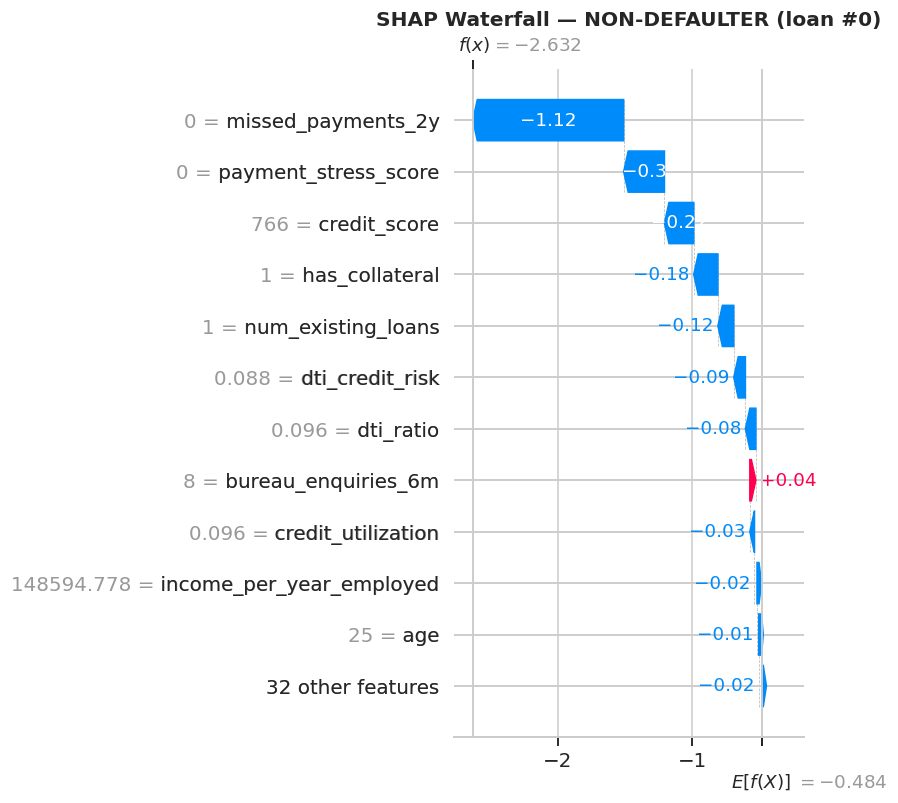

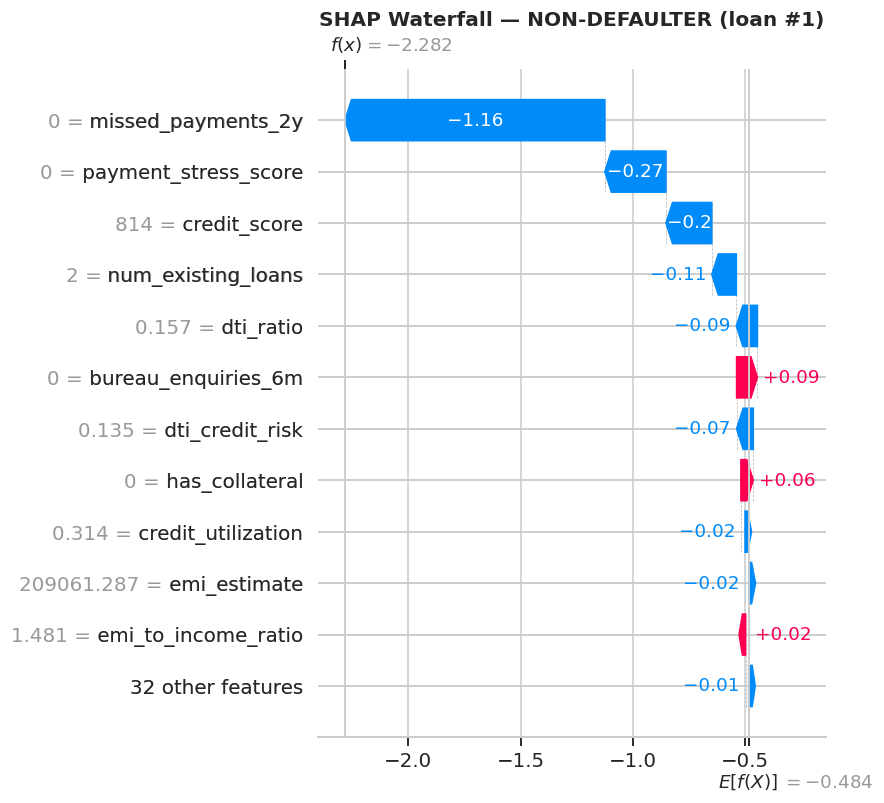

In [29]:
# ── 8.4  SHAP waterfall plots — 2 defaulters + 2 non-defaulters ────────────────
# Find actual defaulters and non-defaulters in the test-like portion
default_idx     = y[y == 1].index[:2].tolist()
non_default_idx = y[y == 0].index[:2].tolist()

shap_exp = explainer(X)
if isinstance(shap_exp.values, list):
    # Wrap as Explanation for class 1
    shap_exp_cls1 = shap.Explanation(
        values     = shap_exp.values[..., 1],
        base_values= shap_exp.base_values[..., 1],
        data       = shap_exp.data,
        feature_names = X.columns.tolist()
    )
else:
    shap_exp_cls1 = shap_exp

for idx in default_idx:
    row_pos = X.index.get_loc(idx)
    plt.figure()
    shap.plots.waterfall(shap_exp_cls1[row_pos], max_display=12, show=False)
    plt.title(f'SHAP Waterfall — DEFAULTER (loan #{idx})', fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'shap_waterfall_default_{idx}.png', bbox_inches='tight', dpi=130)
    plt.show()

for idx in non_default_idx:
    row_pos = X.index.get_loc(idx)
    plt.figure()
    shap.plots.waterfall(shap_exp_cls1[row_pos], max_display=12, show=False)
    plt.title(f'SHAP Waterfall — NON-DEFAULTER (loan #{idx})', fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'shap_waterfall_nondefault_{idx}.png', bbox_inches='tight', dpi=130)
    plt.show()

In [30]:
# ── 8.5  Domain alignment check ───────────────────────────────────────────────
print('''
=== SHAP Domain Alignment Analysis ===

Expected top drivers based on credit risk theory (Basel II / RBI guidelines):
  1. credit_score           → Higher score = lower default risk  ✅ EXPECTED
  2. missed_payments_2y     → More missed EMIs = higher risk     ✅ EXPECTED
  3. dti_ratio / dti_credit_risk → High DTI = over-leveraged     ✅ EXPECTED
  4. loan_to_income_ratio   → Loan > income capacity = risky     ✅ EXPECTED
  5. bureau_enquiries_6m    → Many enquiries = credit hungry      ✅ EXPECTED
  6. savings_to_loan_ratio  → Low savings buffer = high risk      ✅ EXPECTED

  gender / urban_rural      → Should be LOW in SHAP importance   ← CHECK THIS!

Fairness conclusion: If gender/geography appear in top-5 SHAP features,
we should investigate and potentially apply a fairness constraint.
''')


=== SHAP Domain Alignment Analysis ===

Expected top drivers based on credit risk theory (Basel II / RBI guidelines):
  1. credit_score           → Higher score = lower default risk  ✅ EXPECTED
  2. missed_payments_2y     → More missed EMIs = higher risk     ✅ EXPECTED
  3. dti_ratio / dti_credit_risk → High DTI = over-leveraged     ✅ EXPECTED
  4. loan_to_income_ratio   → Loan > income capacity = risky     ✅ EXPECTED
  5. bureau_enquiries_6m    → Many enquiries = credit hungry      ✅ EXPECTED
  6. savings_to_loan_ratio  → Low savings buffer = high risk      ✅ EXPECTED

  gender / urban_rural      → Should be LOW in SHAP importance   ← CHECK THIS!

Fairness conclusion: If gender/geography appear in top-5 SHAP features,
we should investigate and potentially apply a fairness constraint.



## 9️⃣  Generate Test Predictions

In [31]:
# ── 9.1  Predict on test set ───────────────────────────────────────────────────
test_probs  = best_lgb.predict_proba(X_test_raw)[:, 1]
test_preds  = (test_probs >= BEST_THRESHOLD).astype(int)

# Risk band mapping (useful for the dashboard)
def risk_band(p):
    if p >= 0.6:  return 'HIGH'
    elif p >= 0.35: return 'MEDIUM'
    else:           return 'LOW'

submission = pd.DataFrame({
    'loan_id'         : test_raw['loan_id'],
    'default_prob'    : test_probs.round(4),
    'default_flag'    : test_preds,
    'risk_band'       : [risk_band(p) for p in test_probs]
})

submission.to_csv('submission.csv', index=False)
print('Submission saved: submission.csv')
print(f'Predicted defaults: {test_preds.sum()} / {len(test_preds)} ({test_preds.mean():.2%})')
print(f'\nRisk band distribution:')
print(submission['risk_band'].value_counts())
submission.head()

Submission saved: submission.csv
Predicted defaults: 616 / 2500 (24.64%)

Risk band distribution:
risk_band
LOW       1432
HIGH       648
MEDIUM     420
Name: count, dtype: int64


,loan_id,default_prob,default_flag,risk_band
0,LN0009468,0.1595,0,LOW
1,LN0014847,0.0795,0,LOW
2,LN0011993,0.1381,0,LOW
3,LN0012068,0.3736,0,MEDIUM
4,LN0001934,0.6600,1,HIGH


In [34]:
# ── SAVE EVERYTHING FOR ROUND 2 ──────────────────────────────
import pickle

# 1. Save the trained LightGBM model
with open('lightgbm_model.pkl', 'wb') as f:
    pickle.dump(best_lgb, f)
print("✅ Model saved")

# 2. Save the Target Encoder
with open('target_encoder.pkl', 'wb') as f:
    pickle.dump(te, f)
print("✅ Target encoder saved")

# 3. Save the feature column names
# (needed to align new applicant data correctly)
feature_columns = X.columns.tolist()
with open('feature_columns.pkl', 'wb') as f:
    pickle.dump(feature_columns, f)
print("✅ Feature columns saved")

# 4. Save the outlier bounds
# (needed to cap new applicant data same way)
with open('outlier_bounds.pkl', 'wb') as f:
    pickle.dump(outlier_bounds, f)
print("✅ Outlier bounds saved")

# 5. Save the best threshold
with open('best_threshold.pkl', 'wb') as f:
    pickle.dump(BEST_THRESHOLD, f)
print(f"✅ Threshold saved: {BEST_THRESHOLD:.3f}")

# 6. Save OHE column list
with open('ohe_cols.pkl', 'wb') as f:
    pickle.dump(OHE_COLS, f)
print("✅ OHE columns saved")

# 7. Save target encode column list
with open('target_encode_cols.pkl', 'wb') as f:
    pickle.dump(TARGET_ENCODE_COLS, f)
print("✅ Target encode columns saved")

print("\n✅ ALL FILES SAVED SUCCESSFULLY!")

# ── DOWNLOAD ALL FILES ────────────────────────────────────────
from google.colab import files

files.download('lightgbm_model.pkl')
files.download('target_encoder.pkl')
files.download('feature_columns.pkl')
files.download('outlier_bounds.pkl')
files.download('best_threshold.pkl')
files.download('ohe_cols.pkl')
files.download('target_encode_cols.pkl')

print("✅ All files downloaded to your computer!")

✅ Model saved
✅ Target encoder saved
✅ Feature columns saved
✅ Outlier bounds saved
✅ Threshold saved: 0.634
✅ OHE columns saved
✅ Target encode columns saved

✅ ALL FILES SAVED SUCCESSFULLY!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ All files downloaded to your computer!
